## <code>data-conduit</code>: Overview and Workflow Guide
**A Python Toolkit for Constructing Standardised, Reusable Data Pipelines for Multi-Stream Experimental Data**

## Table of Contents

1. [What is `data-conduit`?](#1-what-is-data-conduit)
2. [How does `data-conduit` work?](#2-how-does-data-conduit-work)
3. [An overview of `data-conduit`'s modules](#3-an-overview-of-data-conduits-modules)
4. [Part 1: IO — Discovering and reading files](#4-io)
5. [Part 2: The object layer — DataSource, Device, FileTypeData, MultiSource, MultiDevice](#5-object-layer)
6. [Part 3: TTL synchronisation and temporal alignment](#6-ttlsync)
7. [Putting it all together](#7-putting-it-all-together)
8. [Useful information and links](#8-links)

-----
## 1. What is `data-conduit`?

`data-conduit` is a Python toolkit for converting outputs from multiple data acquisition sources into consistent, unified data structures that can be used for subsequent analysis.

This library was originally designed for experimental neuroscience labs working with the [Bonsai](https://bonsai-rx.org/) and [HARP](https://harp-tech.org/) ecosystems as part of their workflow, with raw experimental data stored in directories based on the [NeuroBlueprint](https://neuroblueprint.neuroinformatics.dev/) standard. However, most functionalities provided by `data-conduit` are modular and flexible, and should be compatible with other data acquisition platforms, as well as other data conventions.`data-conduit` is concerned with using a consistent structure to automate data processing workflows, rather than enforcing any one particular format.

These workflows are designed to integrate with tools from the broader [neuroinformatics.dev](https://neuroinformatics.dev/) ecosystem, including [datashuttle](https://datashuttle.neuroinformatics.dev/) for data management and [movement](https://movement.neuroinformatics.dev/) for pose tracking analysis.

The functionality of `data-conduit` can be broadly grouped into the following categories:

1. **Automated discovery and reading** of data files from directory trees.
2. **Processing and conversion** of raw data into unified data structures (nested dicts of DataFrames, xarray DataArrays).
3. **Flexible querying utilities** to interact with unified data structures across devices, registers, and data types.
4. **Temporal alignment** of different experimental data streams (e.g. Bonsai/HARP ↔ Neuropixels via TTL synchronisation).
5. **Segmentation** of data using event-based windowing and boolean run-length encoding.

-----
## 2. How does `data-conduit` work?

To explain how `data-conduit` works, it is helpful to first explain how data from HARP devices would normally need to be extracted using the `harp-python` API.

When working with HARP devices, users will find that their experimental data is organised into a hierarchical folder structure, with each device having its own subfolder containing multiple `.bin` files corresponding to different registers. The naming convention follows a consistent pattern: `DeviceName_RegisterAddress_Timestamp.bin`.

A user wanting to access a specific register's data must:
1. Create a device reader from a YAML schema file
2. Know the correct register name and address
3. Construct the correct file path
4. Read the binary data into a DataFrame

In [1]:
#======== How harp-python works natively
import harp
device_yaml_path = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/device.yml'
device_register_path = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/JPVA191B_23102025_run1_g0/bonsai/Behavior4/Behavior4_32_1904-01-01T02-00-00.bin'

reader = harp.create_reader(device_yaml_path)
reader.DigitalInputState.read(device_register_path)

,DIPort0,DIPort1,DIPort2,DI3
Time,,,,
8477.558592,True,False,False,False
8477.641888,False,False,False,False
8477.706016,True,False,False,False
8477.838816,False,False,False,False
9536.453216,False,True,False,False
9536.747008,False,False,False,False


**The Problem:**

Whilst these tools provide a basic framework for accessing HARP device data, users will often find themselves working with experiment logs containing multiple devices and multiple registers per device, as well as needing to collate data across sessions, devices, and data types. Using the above approach requires manually repeating these steps for every register of interest across every device and session, which both a time-consuming and error-prone process.

**The Solution:**

`data-conduit` exploits the one thing that is consistent across all experimental sessions: **the directory structure itself**. 

For example, data about a particular component connected to a HARP board will always reside at `[device]/[register]/columns`. By defining a mapping that specifies where each variable of interest is located within the experimental directory; such as by using device, register, and column identifiers, the library can automatically discover, load, and organise all relevant data into consistent structures that mirror the physical layout of the rig.

This means users work with **stable variable names** instead of file paths. The same code works unchanged across sessions, rigs, and experiments, as long as the directory layout is consistent.

----
## 3. An overview of `data-conduit`'s modules

### Package structure

```
data_conduit/
├── io/                  # File discovery and reading
│   ├── io_core.py       # collect_folders, collect_file_paths, collect_dfs
│   └── readers.py       # read_csv, read_harp_bin, read_json, etc.
├── harptools/           # HARP-specific loading
│   └── harptools_core.py  # collect_harp_dfs
├── utils/               # Selector utilities
│   └── utils_core.py    # starts_with, _matches_selector, _parse_selectors
├── datasource/          # Generic object layer
│   ├── datasource_core.py  # DataSource base class
│   ├── devices.py       # Device, SoundCard, CameraStart, Camera0Frames
│   └── filetypes.py     # FileTypeData, ExperimentEvents, RotationData, etc.
├── multisource/         # Multi-stream alignment layer
│   ├── multisource_core.py  # MultiSource
│   └── multidevice.py   # MultiDevice, Nosepoke
├── virtualarrays/       # DataArray construction + querying
│   ├── virtual_arrays_core.py  # construct_data_array, construct_lookup_array
│   ├── base_queries.py  # ulookup
│   └── custom_lookup_template.py  # .ulookup accessor
├── timestamps/          # Timestamp extraction
│   └── timestamps_core.py
├── globaltimes/         # Global clock + index mapping
│   └── globaltimes_core.py
├── ttlsync/             # TTL pulse alignment
│   ├── ttlsync_core.py  # extract_ttl_segments, TTLSyncModel, etc.
│   └── ttl_visualisation.py
├── segment/             # Event windowing + segmentation
├── validators/          # Data validation
└── deprecated/          # Legacy compatibility wrappers
```

### How the layers connect

`data-conduit` is organised into three conceptual layers, each building on the one below:

**Layer 1| IO (functions):** Low-level utilities that discover directories, find files, and read them into DataFrames. These are pure functions with no state.

**Layer 2| Object layer (classes):** Classes that use the IO layer to load data and then organise it into named outputs. There are two families:
- **DataSource** → **Device** / **FileTypeData**: For cases where each output maps to a single location in the directory tree (one device, one register). Produces a dict of named `xr.DataArray` objects.
- **MultiSource** → **MultiDevice**: For cases where a single output combines data from *multiple* locations (e.g. nosepoke activations spread across multiple HARP boards). Produces unified DataArrays with virtual coordinate lookup.

**Layer 3| Alignment & analysis (functions + classes):** Temporal alignment (TTL sync, global clock), segmentation, and querying utilities that operate on the DataArrays produced by Layer 2.

| Layer | Module | Key exports | Purpose |
|---|---|---|---|
| IO | `io` | `collect_folders`, `collect_file_paths`, `collect_dfs` | Walk directories, read files into nested dicts |
| IO | `harptools` | `collect_harp_dfs` | HARP-specific wrapper: collapse, rekey, filter |
| Object | `datasource` | `DataSource` | Generic: dfs_dict → named DataArrays |
| Object | `datasource.devices` | `Device`, `SoundCard`, `Camera0Frames` | HARP device loading + DataSource |
| Object | `datasource.filetypes` | `FileTypeData`, `ExperimentEvents`, `VideoData` | CSV/JSON/YAML loading + DataSource |
| Object | `multisource` | `MultiSource` | Virtual-map aligned multi-stream arrays |
| Object | `multisource.multidevice` | `MultiDevice`, `Nosepoke` | HARP loading + MultiSource |
| Query | `virtualarrays` | `ulookup`, `.ulookup` accessor | Query DataArrays by virtual coordinates |
| Align | `ttlsync` | `extract_ttl_segments`, `TTLSyncModel` | TTL pulse alignment between clock domains |
| Align | `globaltimes` | `create_global_clock`, `index_map_util` | Shared timebase + index mapping |

----
## 4. Part 1: IO| Discovering and reading files

The IO layer provides the building blocks that every higher-level class uses internally. This is central to much of the rest of the library, as every class in `data-conduit` ultimately calls these functions at some stage.


### 4.1 Setup

In [2]:
#======== User-Configurable Paths ==============================================
experiment_directory_path = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42'
harp_device_yaml_path     = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/device.yml'
soundcard_yaml_path       = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/soundcard.yml'
npx_sync_path             = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/sync_channel_1014.npy'

### 4.2 Directory discovery

A typical Bonsai experiment produces a directory tree like:

```
experiment/
├── Behavior0/
│   └── Behavior0/
│       ├── Behavior0_32_2024-01-01T12-00-00.bin
│       └── Behavior0_34_2024-01-01T12-00-00.bin
├── Behavior1/ ...
├── SoundCard/ ...
├── ExperimentEvents/
│   └── ExperimentEvents.csv
└── VideoData/
    └── VideoData.csv
```

`collect_folders` lists subdirectories. `collect_file_paths` finds files matching given extensions.

In [3]:
from data_conduit.io import collect_folders, collect_file_paths

In [4]:
# List all top-level folders
folders = collect_folders(experiment_directory_path)
print('Top-level folders:')
for f in folders:
    print(f'  {f.name}')

print()

# Find all .bin files
bin_files = collect_file_paths(base_path= experiment_directory_path, file_pattern='*.bin')
print(f'Found {len(bin_files)} .bin files (showing first 5):')
for p in bin_files:
    print(f'  {p}')

Top-level folders:
  Behavior0
  Behavior1
  Behavior2
  Behavior3
  Behavior4
  Behavior5
  ExperimentEvents
  InnerRotation
  NosepokeRotation
  OuterRotation
  SessionSettings
  SoundCard
  VideoData
  VisualEnvironment

Found 7 .bin files (showing first 5):
  Behavior0
  Behavior1
  Behavior2
  Behavior3
  Behavior4
  Behavior5
  SoundCard


### 4.3 `collect_dfs`| the core directory walker

`collect_dfs` is the engine behind everything else. It walks a directory tree, reads every file it can, and returns a **nested dictionary** that mirrors the folder structure, where each leaf is a DataFrame.

Users control behaviour with two things:
- **`readers`**: a dict mapping file extensions to reader functions (e.g. `{'.csv': read_csv}`)
- **`l{n}_selector`**: level selectors that filter which folders/files are included at each depth

The result is always a nested dict. This is the fundamental data structure that flows through the entire library.

In [5]:
from data_conduit.io import collect_dfs, read_csv

# Load all CSV files from the experiment directory
csv_dfs = collect_dfs(
    base_path=experiment_directory_path,
    readers={'.csv': read_csv},
    verbose=True,
)

print('\nLoaded structure:')
for key, value in csv_dfs.items():
    if isinstance(value, dict):
        print(f'  {key}/ -> {list(value.keys())}')
    else:
        print(f'  {key} -> {type(value).__name__} {getattr(value, "shape", "")}')

Failed to read /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42/VisualEnvironment/VisualEnvironment_1904-01-01T08-00-00.csv with reader for .csv: Expected 2 fields in line 3, saw 6. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.

Loaded structure:
  Behavior0/ -> []
  Behavior1/ -> []
  Behavior2/ -> []
  Behavior3/ -> []
  Behavior4/ -> []
  Behavior5/ -> []
  ExperimentEvents/ -> ['ExperimentEvents_1904-01-01T08-00-00']
  InnerRotation/ -> ['InnerRotation_1904-01-01T08-00-00']
  NosepokeRotation/ -> ['NosepokeRotation_1904-01-01T08-00-00']
  OuterRotation/ -> ['OuterRotation_1904-01-01T08-00-00']
  SessionSettings/ -> []
  SoundCard/ -> []
  VideoData/ -> ['VideoData_1904-01-01T08-00-00']
  VisualEnvironment/ -> []


### 4.4 Level selectors| filtering the directory tree

Level selectors filter at any depth of the directory tree. They accept:
- **A string**: exact match (`l0_selector='Behavior0'`)
- **A list**: match any item (`l0_selector=['Behavior0', 'Behavior1']`)
- **A callable**: custom logic (`l0_selector=starts_with('Behavior')`)
- **None**: include everything (default)

The `starts_with` helper is particularly useful for Bonsai's naming convention where `Behavior0`, `Behavior1`, etc. share a common prefix.

In [6]:
from data_conduit.utils import starts_with

# Load only ExperimentEvents CSVs
events_only = collect_dfs(
    base_path=experiment_directory_path,
    readers={'.csv': read_csv},
    l0_selector=starts_with('ExperimentEvents'),
)
print('Filtered to ExperimentEvents:', list(events_only.keys()))

# Load only Behavior folders
behavior_csvs = collect_dfs(
    base_path=experiment_directory_path,
    readers={'.csv': read_csv},
    l0_selector=starts_with('Behavior'),
)
print('Filtered to Behavior*:', list(behavior_csvs.keys()))

Filtered to ExperimentEvents: ['ExperimentEvents']
Filtered to Behavior*: ['Behavior0', 'Behavior1', 'Behavior2', 'Behavior3', 'Behavior4', 'Behavior5']


### 4.5 Readers| adding custom file formats

Any function with the signature `(path, **kwargs) -> DataFrame` can be used as a reader. Just map it to a file extension. The built-in readers cover `.csv`, `.json`, `.bin` (HARP), `.jsonl`, `.yml`/`.yaml`.

In [7]:
import pandas as pd

# Example: custom tab-separated reader
def read_tsv(path, **kwargs):
    return pd.read_csv(path, sep='\t', index_col=0, **kwargs)

# Use it like any built-in reader:
# tsv_dfs = collect_dfs(base_path, readers={'.tsv': read_tsv})

# You can also mix readers for different extensions:
# mixed_dfs = collect_dfs(base_path, readers={'.csv': read_csv, '.tsv': read_tsv})

### 4.6 `collect_harp_dfs`| HARP-specific loading

`collect_harp_dfs` wraps `collect_dfs` for the specific needs of HARP binary data. It:

1. Calls `collect_dfs` with the HARP `.bin` reader and a `device_type` prefix filter
2. **Collapses** Bonsai's duplicated device folders (`Behavior0/Behavior0/` → `Behavior0/`)
3. **Rekeys** file stems from `Behavior0_32_timestamp` to just `32` (the register address)
4. **Filters** to only the registers you asked for
5. **Warns** about any expected devices or registers that are missing

The result is a clean `{device: {register: DataFrame}}` dict.

In [8]:
from data_conduit.harptools import collect_harp_dfs

behavior_dfs = collect_harp_dfs(
    base_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_registers={'Behavior0': ['32', '34'], 'Behavior1': ['32', '34']},
    verbose=True,
)

print('\nResult:')
for dev, regs in behavior_dfs.items():
    for reg, df in regs.items():
        print(f'  {dev}/{reg}: {df.shape}')
        display(df.head(3))

Failed to read /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42/Behavior4/Behavior4_1904-01-01T08-00-00.bin with reader for .bin: invalid literal for int() with base 10: '1904-01-01T08-00-00'
Failed to read /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42/Behavior5/Behavior5_1904-01-01T08-00-00.bin with reader for .bin: invalid literal for int() with base 10: '1904-01-01T08-00-00'

Result:
  Behavior0/34: (283, 14)


,DOPort0,DOPort1,DOPort2,SupplyPort0,SupplyPort1,SupplyPort2,Led0,Led1,Rgb0,Rgb1,DO0,DO1,DO2,DO3
Time,,,,,,,,,,,,,,
29876.159488,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29879.203488,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29881.924480,False,False,False,False,False,False,False,False,False,False,False,True,False,False


  Behavior1/34: (283, 14)


,DOPort0,DOPort1,DOPort2,SupplyPort0,SupplyPort1,SupplyPort2,Led0,Led1,Rgb0,Rgb1,DO0,DO1,DO2,DO3
Time,,,,,,,,,,,,,,
29876.159488,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29879.204480,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29881.924480,False,False,False,False,False,False,False,False,False,False,False,True,False,False


  Behavior2/34: (283, 14)


...

,CameraOutput0,CameraOutput1
Time,,
29874.792544,True,False


  Behavior5/8: (969, 1)


,TimestampSeconds
Time,
29873.0,29873
29874.0,29874
29875.0,29875


  Behavior5/92: (58013, 1)


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True


----
## 5. Part 2: The object layer

### Why do we need classes on top of the IO functions?

`collect_dfs` and `collect_harp_dfs` give you nested dicts of DataFrames. Whilst this is already an obvious improvement over manually extracting each data file, users shalll frequently want other features such as:

1. **Named outputs**: instead of navigating `dfs_dict['Behavior0']['32']`, users would often prefer to use more legible naming such as `soundcard.data_arrays['PlaySoundFreq']` .
2. **Automatic loading**: pass an experiment path and get results, without manually calling IO functions
3. **Reusable presets**: common device configurations (SoundCard, Camera, Nosepoke) should be one-liners
4. **Multi-device combination**: when the same data type spans multiple files, users will require a unified DataArray with a shared time axis to view them simultaneously.

The object layer provides two families of classes to address these needs.

### 5.1 DataSource| the generic base

`DataSource` is the simplest object class. It takes a `dfs_dict` (or builds one via `collect_dfs`) and extracts named `xr.DataArray` outputs using **level selectors**. This uses the same `l{n}_selector` pattern from `collect_dfs`.

```python
# The datasource_data_arrays parameter maps friendly names to selectors:
datasource_data_arrays = {
    'PlaySoundFreq': {'l0_selector': 'SoundCard', 'l1_selector': '32'},
    'StopLog':       {'l0_selector': 'SoundCard', 'l1_selector': '33'},
}
```

Each selector navigates the nested dict to find the right DataFrame, converts it to a DataArray, and stores it under the friendly name. If the selector matches exactly one leaf, the friendly name is used directly. If it matches multiple, each gets a disambiguated key.

`DataSource` will most often not be used directly, but rather custom subclasses such as `Device` and `FileTypeData` will be more practical, as they incorporate further functionalities specific to the use-case at hand.

### 5.2 Device| HARP binary data

`Device` extends `DataSource` for HARP devices. It:
1. Calls `collect_harp_dfs` to build a clean dfs_dict
2. Passes it to `DataSource` with `device_data_arrays` for named output extraction

**Presets** like `SoundCard`, `CameraStart`, and `Camera0Frames` set sensible defaults so common devices are one-liners.

In [9]:
from data_conduit.datasource.devices import Device, SoundCard, Camera0Frames

#======== Using Device directly with explicit config
soundcard_demo = Device(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
    device_type='SoundCard',
    device_list=['SoundCard'],
    device_registers={'SoundCard': ['8', '32', '33', '35']},
    device_data_arrays={
        'PlaySoundFreq':    {'l0_selector': 'SoundCard', 'l1_selector': '32'},
        'StopLog':          {'l0_selector': 'SoundCard', 'l1_selector': '33'},
        'AttenuationRight': {'l0_selector': 'SoundCard', 'l1_selector': '35'},
    },
)

print("Device data_arrays:", list(soundcard_demo.data_arrays.keys()))
for name, da in soundcard_demo.data_arrays.items():
    print(f"  {name}: {da.sizes}")
    display(da.to_dataframe().head(3))


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
Device data_arrays: ['PlaySoundFreq', 'StopLog', 'AttenuationRight']
  PlaySoundFreq: Frozen({'Time': 4})


,PlaySoundOrFrequency
Time,
30093.312480,880
30093.313056,880
30358.165504,880


  StopLog: Frozen({'Time': 2})


,Stop
Time,
30093.350496,1
30358.169504,1


  AttenuationRight: Frozen({'Time': 2})


,AttenuationRight
Time,
30093.313504,1000
30358.166496,1000


In [10]:
#======== Or use the SoundCard preset (same result, less typing)
soundcard_preset = SoundCard(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
)
print("SoundCard preset data_arrays:", list(soundcard_preset.data_arrays.keys()))


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
SoundCard preset data_arrays: ['PlaySoundFreq', 'StopLog', 'AttenuationRight']


In [11]:
#======== Camera0Frames preset
camera_frames = Camera0Frames(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
)

print("Camera0Frames data_arrays:", list(camera_frames.data_arrays.keys()))
for name, da in camera_frames.data_arrays.items():
    display(da.to_dataframe().head(3))


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
Camera0Frames data_arrays: ['Behavior0_Camera0Frame', 'Behavior1_Camera0Frame', 'Behavior2_Camera0Frame', 'Behavior3_Camera0Frame', 'Behavior4_Camera0Frame', 'Behavior5_Camera0Frame']


,FrameAcquired
Time,
29874.791584,True
29874.808224,True
29874.824896,True


,FrameAcquired
Time,
29874.791584,True
29874.808224,True
29874.824896,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825888,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825888,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True


### 5.3 FileTypeData | CSV, JSON, YAML files

Alongside HARP binary data, Bonsai workflows produce CSV, JSONL, and YAML files for experiment events, video metadata, visual environments, and session settings.

`FileTypeData` extends `DataSource` for these file types. It maps a `file_type` string (e.g. `'csv'`) to the appropriate reader, handles Bonsai's double-folder quirk, applies column/index renaming, and splits JSONL/YAML files into metadata + trials.

Like Device, it produces `.data_arrays` as the primary interface. A `.df` convenience property is also available for backward compatibility, and returns the single leaf DataFrame when there's only one file loaded.

In [13]:
from data_conduit.datasource.filetypes import ExperimentEvents, VideoData, VisualEnvironment

#======== ExperimentEvents
events = ExperimentEvents(experiment_directory_path=experiment_directory_path)
print(f"ExperimentEvents: {events.df} events")
print(f"data_arrays: {list(events.data_arrays.keys())}")
display(events.df)


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
ExperimentEvents:                                                           Event
Time                                                           
29872.322976                                   Workflow started
29874.790976                               Request camera start
29875.153984                                   Start Sync Pulse
29875.629984                                  Start trial logic
29875.894976                                        Trial start
29875.894976                                  Rotating nosepoke
29875.924992                           Start mismatch rotations
29878.962976                         Performing outer rotations
29888.980992  Target zone available (X Y : 395 290 - Radius ...
30113.034976                              Target zone trigg

,Event
Time,
29872.322976,Workflow started
29874.790976,Request camera start
29875.153984,Start Sync Pulse
29875.629984,Start trial logic
29875.894976,Trial start
29875.894976,Rotating nosepoke
29875.924992,Start mismatch rotations
29878.962976,Performing outer rotations
29888.980992,Target zone available (X Y : 395 290 - Radius ...


In [14]:
#======== VideoData
video_data = VideoData(experiment_directory_path=experiment_directory_path)
print(f"VideoData: {video_data.df} rows")
display(video_data.df)


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
VideoData:              FrameID       Timestamp
Time                                
29874.792576  489850  29849558403592
29874.809216  489851  29849575068920
29874.825856  489852  29849591735704
29874.842528  489853  29849608401160
29874.859200  489854  29849625063616
...              ...             ...
30841.322496  547844  30816074286136
30841.339168  547845  30816090952512
30841.355840  547846  30816107618864
30841.372480  547847  30816124285056
30841.389152  547848  30816140950840

[57999 rows x 2 columns] rows


,FrameID,Timestamp
Time,,
29874.792576,489850,29849558403592
29874.809216,489851,29849575068920
29874.825856,489852,29849591735704
29874.842528,489853,29849608401160
29874.859200,489854,29849625063616
...,...,...
30841.322496,547844,30816074286136
30841.339168,547845,30816090952512
30841.355840,547846,30816107618864


In [15]:
#======== VisualEnvironment
vis_env = VisualEnvironment(experiment_directory_path=experiment_directory_path)
print(f"VisualEnvironment: {vis_env.df.shape[0]} rows, columns: {list(vis_env.df.columns)}")
display(vis_env.df.head())


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
VisualEnvironment: 4 rows, columns: ['Value', 'Landmark', 'Landmark_Proximal', 'Gratings', 'Firefly']


,Value,Landmark,Landmark_Proximal,Gratings,Firefly
Time,,,,,
29875.880000,Visual environment OFF,None,None,None,None
29878.962976,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF
30113.132992,Visual environment OFF,None,None,None,None
30116.152000,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF


### 5.4 MultiSource| combining data across multiple sources

`DataSource` works well when each output maps to a single location in the directory tree. However, with workflows such as the example here, users can find themselves with peripherals or other data that spans multiple locations. 

Consider a rig with 2 HARP Behavior boards, each with 3 nosepoke ports. The activation data for nosepoke 0 lives at `Behavior0/register_32/DIPort0`, while nosepoke 5 is at `Behavior1/register_32/DIPort2`. To analyse all 6 nosepokes together requires a single DataArray with the following:
- A **Time** dimension (merged timestamps from both boards)
- A **peripherals** dimension (6 nosepoke names: NP_0 through NP_5)
- **Virtual coordinates** (device, register, localID) attached to each peripheral to allow them to be queried based on multiple associated values. 

This is what `MultiSource` does. It takes:
1. A `dfs_dict` (nested dict of DataFrames)
2. A `virtual_maps` dict that maps each global name → {device, register, localID}
3. A list of `data_keys` (one per data type: Activations, LEDs, Valves, Rewards)

And produces unified DataArrays + lookup arrays for each data key.

### 5.5 Defining the rig layout

Before using MultiSource/MultiDevice, the user is required to define the physical wiring of their setup. This is the only manual step, allowing the rest to be automated.

| Concept | What it means | Example |
|---|---|---|
| **Device** | A HARP board in the experiment directory | `Behavior0`, `Behavior1` |
| **Register** | An address on a device logging a particular signal | `32` (DigitalInputState), `34` (DigitalOutputState) |
| **LocalID** | A column within a register DataFrame — one per physical port | `DIPort0`, `DOPort1` |
| **Global name** | A user-chosen label for a specific peripheral | `Nosepoke0`, `Nosepoke3` |
| **Virtual map** | Maps each global name → `{device, register, localID}` | `{'Nosepoke0': {'device': 'Behavior0', ...}}` |

In [16]:
#======== Rig Layout =============================================================
# For this demo: 2 Behavior boards, 3 nosepokes each = 6 total

device_list = ['Behavior0', 'Behavior1']
device_registers = {
    'Behavior0': ['32', '34'],
    'Behavior1': ['32', '34'],
}

peripheral_list = [
    'Nosepoke0', 'Nosepoke1', 'Nosepoke2',   # Behavior0
    'Nosepoke3', 'Nosepoke4', 'Nosepoke5',   # Behavior1
]

#======== Virtual Maps ===========================================================
# One map per data type. Each maps a global name to (device, register, localID).

virtual_maps = {
    'Activations': {
        'Nosepoke0': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'},
        'Nosepoke1': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'},
        'Nosepoke2': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'},
        'Nosepoke3': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort0'},
        'Nosepoke4': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort1'},
        'Nosepoke5': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort2'},
    },
    'LED_Activations': {
        'Nosepoke0': {'device': 'Behavior0', 'register': '34', 'localID': 'DOPort0'},
        'Nosepoke1': {'device': 'Behavior0', 'register': '34', 'localID': 'DOPort1'},
        'Nosepoke2': {'device': 'Behavior0', 'register': '34', 'localID': 'DOPort2'},
        'Nosepoke3': {'device': 'Behavior1', 'register': '34', 'localID': 'DOPort0'},
        'Nosepoke4': {'device': 'Behavior1', 'register': '34', 'localID': 'DOPort1'},
        'Nosepoke5': {'device': 'Behavior1', 'register': '34', 'localID': 'DOPort2'},
    },
}
data_keys = list(virtual_maps.keys())

print("Activations virtual_map:")
for ch, coords in virtual_maps['Activations'].items():
    print(f"  {ch} → {coords}")

Activations virtual_map:
  Nosepoke0 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke1 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke2 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'}
  Nosepoke3 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke4 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke5 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort2'}


### 5.6 MultiDevice| HARP loading + MultiSource

`MultiDevice` combines `collect_harp_dfs` (for loading) with `MultiSource` (for virtual-map construction). When instantiated with an `experiment_directory_path`, it automatically:

1. Calls `collect_harp_dfs` to load DataFrames from all device folders
2. Collects and merges timestamps across devices for each data_key
3. Constructs a base `xr.DataArray` per data_key with unified peripheral names and a shared time axis
4. Constructs a lookup array per data_key mapping each peripheral to its virtual coordinates
5. Fills the DataArrays with actual values from the loaded DataFrames

In [17]:
from data_conduit.multisource.multidevice import MultiDevice

multidevice = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers=device_registers,
    virtual_maps=virtual_maps,
    data_keys=data_keys,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    verbose=False,
)

#### Inspecting the outputs

The `data_arrays` dictionary contains one `xr.DataArray` per data_key. Each has:
- A **Time** dimension containing merged, sorted timestamps from all devices
- A **peripherals** dimension containing the unified peripheral names
- Virtual coordinate arrays (**device**, **register**, **localID**) attached along the peripherals dimension

In [29]:
print(f"data_arrays keys: {list(multidevice.data_arrays.keys())}\n")

for dk in multidevice.data_arrays:
    da = multidevice.data_arrays[dk]
    print(f"\n{'='*60}")
    print(f"{dk}: dims={da.dims}, shape={da.shape}")
    print(f"{'='*60}")
    display(da.to_dataframe().unstack('peripherals').drop(columns=['device', 'register', 'localID'], level=0).head(5))

data_arrays keys: ['Activations', 'LED_Activations']


Activations: dims=('Time', 'peripherals'), shape=(1188352, 6)


Activations_data                                          \
peripherals         Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                    
29872.289984              NaN       NaN       NaN       NaN       NaN   
29872.290976              NaN       NaN       NaN       NaN       NaN   
29872.292000              NaN       NaN       NaN       NaN       NaN   
29872.292992              NaN       NaN       NaN       NaN       NaN   
29872.293984              NaN       NaN       NaN       NaN       NaN   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       NaN  
29872.290976       NaN  
29872.292000       NaN  
29872.292992       NaN  
29872.293984       NaN


LED_Activations: dims=('Time', 'peripherals'), shape=(1188352, 6)


LED_Activations_data                                          \
peripherals             Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                        
29872.289984                  NaN       NaN       NaN       NaN       NaN   
29872.290976                  NaN       NaN       NaN       NaN       NaN   
29872.292000                  NaN       NaN       NaN       NaN       NaN   
29872.292992                  NaN       NaN       NaN       NaN       NaN   
29872.293984                  NaN       NaN       NaN       NaN       NaN   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       NaN  
29872.290976       NaN  
29872.292000       NaN  
29872.292992       NaN  
29872.293984       NaN

#### Accessing the underlying DataFrames

The loaded nested dict is always available as `.dfs_dict`.

In [19]:
dfs_dict = multidevice.dfs_dict

print(f"Top-level keys (devices): {list(dfs_dict.keys())}")
for device in dfs_dict:
    print(f"  {device} registers: {list(dfs_dict[device].keys())}")

print(f"\nBehavior0, Register 32:")
display(dfs_dict['Behavior3']['32'].head(5) if '32' in dfs_dict.get('Behavior0', {}) else "Not found")

Top-level keys (devices): ['Behavior0', 'Behavior1', 'Behavior2', 'Behavior3', 'Behavior4', 'Behavior5']
  Behavior0 registers: ['34']
  Behavior1 registers: ['34']
  Behavior2 registers: ['34', '35', '44', '78', '8', '92']
  Behavior3 registers: ['34', '35', '44', '78', '8', '92']
  Behavior4 registers: ['34', '35', '44', '78', '8', '92']
  Behavior5 registers: ['34', '35', '44', '78', '8', '92']

Behavior0, Register 32:


'Not found'

#### The Nosepoke preset

`Nosepoke` is a subclass of `MultiDevice` with pre-built defaults for a standard 6-board × 3-port nosepoke layout (18 nosepokes, 4 data types). For this demo with only 2 boards, we pass custom `virtual_maps` directly to `MultiDevice` instead.

In [20]:
#======= Using our custom 2-board layout
nosepoke = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers=device_registers,
    virtual_maps=virtual_maps,
    data_keys=data_keys,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    fill_value=False,
    verbose=False,
)

for dk in nosepoke.data_arrays:
    da = nosepoke.data_arrays[dk]
    print(f"\n{'='*60}")
    print(f"{dk}")
    print(f"{'='*60}")
    display(da.to_dataframe().unstack('peripherals').drop(
        columns=['device', 'register', 'localID'], level=0, errors='ignore'
    ).head(5))


Activations


Activations_data                                          \
peripherals         Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                    
29872.289984              0.0       0.0       0.0       0.0       0.0   
29872.290976              0.0       0.0       0.0       0.0       0.0   
29872.292000              0.0       0.0       0.0       0.0       0.0   
29872.292992              0.0       0.0       0.0       0.0       0.0   
29872.293984              0.0       0.0       0.0       0.0       0.0   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       0.0  
29872.290976       0.0  
29872.292000       0.0  
29872.292992       0.0  
29872.293984       0.0


LED_Activations


LED_Activations_data                                          \
peripherals             Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                        
29872.289984                  0.0       0.0       0.0       0.0       0.0   
29872.290976                  0.0       0.0       0.0       0.0       0.0   
29872.292000                  0.0       0.0       0.0       0.0       0.0   
29872.292992                  0.0       0.0       0.0       0.0       0.0   
29872.293984                  0.0       0.0       0.0       0.0       0.0   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       0.0  
29872.290976       0.0  
29872.292000       0.0  
29872.292992       0.0  
29872.293984       0.0

### 5.7 `ulookup`| querying virtual coordinates

Every DataArray produced by MultiSource has virtual coordinates attached. The `.ulookup` accessor allows for:
- **Query** which global peripherals match given criteria → returns a list of names
- **Select** the matching slice of the DataArray → returns a new DataArray



In [21]:
#===== Inspect the lookup array
activations_lookup = nosepoke.lookup_arrays['Activations']

print("Lookup array shape:", activations_lookup.shape)
print("Dims:", activations_lookup.dims)
print("Coords:")
for c in activations_lookup.coords:
    print(f"  {c}: {activations_lookup.coords[c].values}")

Lookup array shape: (6,)
Dims: ('peripherals',)
Coords:
  peripherals: ['Nosepoke0' 'Nosepoke1' 'Nosepoke2' 'Nosepoke3' 'Nosepoke4' 'Nosepoke5']
  device: ['Behavior0' 'Behavior0' 'Behavior0' 'Behavior1' 'Behavior1' 'Behavior1']
  register: ['32' '32' '32' '32' '32' '32']
  localID: ['DIPort0' 'DIPort1' 'DIPort2' 'DIPort0' 'DIPort1' 'DIPort2']


In [30]:
da = nosepoke.data_arrays['Activations']

# Which peripherals belong to Behavior0?
b0 = da.ulookup(device='Behavior0')
print(f"da.ulookup(device='Behavior0') → {b0}")

# Which peripherals belong to Behavior1?
b1 = da.ulookup(device='Behavior1')
print(f"da.ulookup(device='Behavior1') → {b1}")

# Combine selectors: Behavior0 + register 32
specific = da.ulookup(device='Behavior0', register='32')
print(f"da.ulookup(device='Behavior0', register='32') → {specific}")

# Slice the DataArray to just Behavior0
b0_data = da.ulookup.select(device='Behavior0')
print(f"\nSliced to Behavior0: {b0_data.sizes}")
display(b0_data.to_dataframe().unstack('peripherals').drop(columns=['device', 'register', 'localID'], level=0).head(5))

da.ulookup(device='Behavior0') → ['Nosepoke0', 'Nosepoke1', 'Nosepoke2']
da.ulookup(device='Behavior1') → ['Nosepoke3', 'Nosepoke4', 'Nosepoke5']
da.ulookup(device='Behavior0', register='32') → ['Nosepoke0', 'Nosepoke1', 'Nosepoke2']

Sliced to Behavior0: Frozen({'Time': 1188352, 'peripherals': 3})


Activations_data                    
peripherals         Nosepoke0 Nosepoke1 Nosepoke2
Time                                             
29872.289984              0.0       0.0       0.0
29872.290976              0.0       0.0       0.0
29872.292000              0.0       0.0       0.0
29872.292992              0.0       0.0       0.0
29872.293984              0.0       0.0       0.0

-----
## 6. Part 3: TTL synchronisation and temporal alignment

### Why alignment is needed

Bonsai/HARP and Neuropixels run on **independent clocks** that drift over time. To combine behavioural events (HARP timestamps) with neural data (NPX sample indices), a shared time reference is required.

**How it works:**

1. A **TTL square-wave pulse train** is generated and recorded on both systems simultaneously — one copy on a HARP Behavior board (digital IO), one on an NPX sync channel.
2. We **extract** pulse start/end times from both recordings.
3. A **linear model** is fitted mapping NPX time → Bonsai time.
4. Any NPX timestamp can then be **converted** to Bonsai time (and vice versa).

### Step 1: Extract Bonsai-side sync pulses

`Device` can then be used to load the sync board's digital output registers, then build a pulse table.

In [23]:
#==== 1| Extract Bonsai-side sync pulses
import pandas as pd
import numpy as np

sync_device = Device(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=['Behavior3'],
    device_registers={'Behavior3': ['34', '35']},
    device_data_arrays={
        'DO1_rise': {'l0_selector': 'Behavior3', 'l1_selector': '34'},
        'DO1_fall': {'l0_selector': 'Behavior3', 'l1_selector': '35'},
    },
)

# Build pulse table from rise/fall timestamps
rise_times = sync_device.data_arrays['DO1_rise'].coords['Time'].values
fall_times = sync_device.data_arrays['DO1_fall'].coords['Time'].values
n_pulses = min(len(rise_times), len(fall_times))

bonsai_pulses = pd.DataFrame({
    'Start': rise_times[:n_pulses],
    'End': fall_times[:n_pulses],
    'Duration': fall_times[:n_pulses] - rise_times[:n_pulses],
})

print(f"Bonsai sync pulses: {len(bonsai_pulses)} detected")
display(bonsai_pulses.head())


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
Bonsai sync pulses: 283 detected


,Start,End,Duration
0,29876.160480,29875.889504,-0.270976
1,29879.204480,29875.890496,-3.313984
2,29881.925504,29875.891488,-6.034016
3,29887.621504,29876.922496,-10.699008
4,29891.362496,29879.740480,-11.622016


### Step 2: Extract NPX-side sync pulses

`extract_ttl_segments` takes a raw sampled waveform and returns a pulse table with Start, End, Duration, and State columns.

In [35]:
#==== 2| Extract NPX-side sync pulses
from data_conduit.ttlsync.ttlsync_core import extract_ttl_segments

npx_raw = np.load(npx_sync_path, allow_pickle=True)
npx_frequency = 1  # set to actual NPX sampling rate (e.g. 30000) if data is in samples
npx_times_array = np.arange(len(npx_raw)) / npx_frequency

npx_pulses, npx_offset = extract_ttl_segments(
    times=npx_times_array,
    values=npx_raw,
    threshold=0.1,
    min_duration=0.0,
    align_to_zero=False,
    drop_inactive=False,
)

print(f"NPX sync pulses: {len(npx_pulses)} detected")
display(npx_pulses.head())

NPX sync pulses: 331 detected


,Start,End,Duration,State
0,0.0,341851.0,341851.0,0
1,341852.0,364711.0,22859.0,1
2,364712.0,433170.0,68458.0,0
3,433171.0,449250.0,16079.0,1
4,449251.0,514801.0,65550.0,0


### Step 3: Align & fit conversion model

`get_ttl_timebase_conversion` aligns both pulse trains, fits a linear model, and optionally visualises the result. Passing `visualisation=True` shows overlaid pulse trains; `error_visualisation_tools=True` adds per-pulse error scatter plots and histograms for verifying sub-millisecond alignment.


Conversion ratio (slope): 0.00006741
Intercept: 29850.411295
R²: 0.9989163957


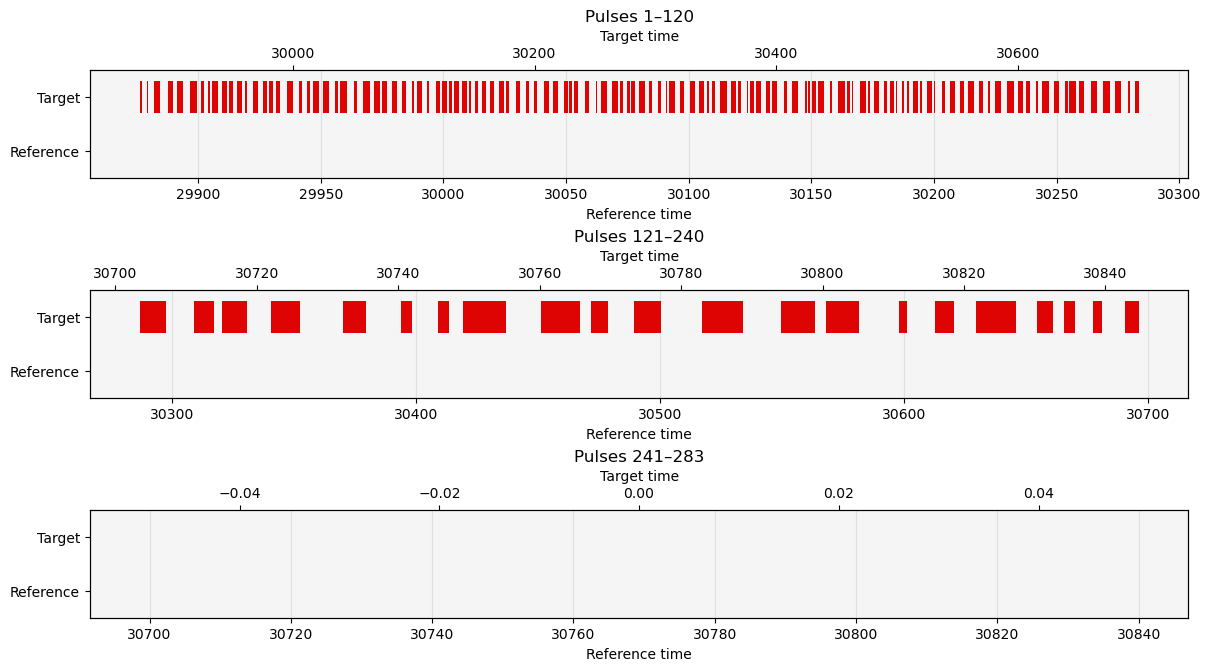

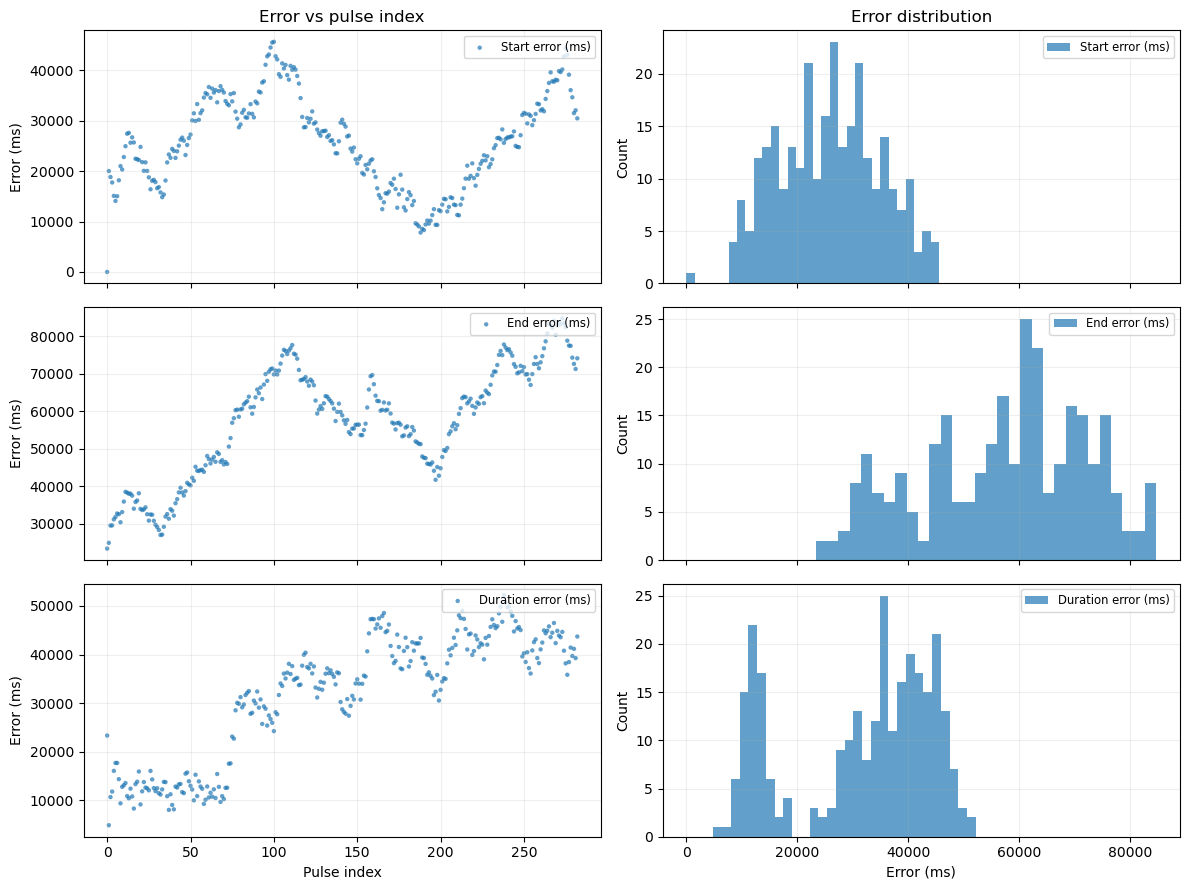

In [36]:
#==== 3| Compute conversion with diagnostics
from data_conduit.ttlsync.ttlsync_core import get_ttl_timebase_conversion

converted_df, conversion_ratio, model, fit_stats = get_ttl_timebase_conversion(
    reference_pulses=bonsai_pulses,
    target_pulses=npx_pulses,
    visualisation=True,
    error_visualisation_tools=True,
    return_details=True,
)

print(f"\nConversion ratio (slope): {model.slope:.8f}")
print(f"Intercept: {model.intercept:.6f}")
print(f"R²: {model.r2:.10f}")

### Step 4: Convert arbitrary NPX timestamps

Once the `TTLSyncModel` has been fitted, converting any NPX timestamp to Bonsai time only requires a single call to `model.transform()`.

In [26]:
#==== 4| Convert NPX pulse times to Bonsai time
npx_in_bonsai = npx_pulses.copy()
npx_in_bonsai['Start'] = model.transform(npx_pulses['Start'].values)
npx_in_bonsai['End'] = model.transform(npx_pulses['End'].values)
npx_in_bonsai['Duration'] = npx_in_bonsai['End'] - npx_in_bonsai['Start']

print("NPX pulse durations converted to Bonsai seconds:")
display(npx_in_bonsai.head())

NPX pulse durations converted to Bonsai seconds:


,Start,End,Duration,State
0,29876.160565,29876.922533,0.761968,1
1,29879.204537,29879.740505,0.535968,1
2,29881.925576,29884.676514,2.750939,1
3,29887.621587,29889.694524,2.072937,1
4,29891.362561,29894.063532,2.700972,1


### 5.8 Global clock and index mapping

`create_global_clock` builds a uniformly-spaced time axis (e.g. at 1-second resolution) that serves as the shared index for all data streams. `index_map_util` then maps any stream's timestamps onto this global axis using nearest-match, giving you aligned indices across all modalities.

In [27]:
from data_conduit.globaltimes.globaltimes_core import create_global_clock, index_map_util

# Define session boundaries
bonsai_start = bonsai_pulses['Start'].iloc[0]
bonsai_end = bonsai_pulses['End'].iloc[-1]
print(f"Session: {bonsai_start:.3f} → {bonsai_end:.3f} s, duration: {bonsai_end - bonsai_start:.3f} s")

global_clock = create_global_clock(
    start_time=0.0,
    end_time=bonsai_end - bonsai_start,
    timestep_interval=1,
    include_end_time=True,
)
print(f"Global clock: {len(global_clock)} bins ({global_clock[0]:.3f} → {global_clock[-1]:.3f} s)")

# Map a data stream onto the global clock
activations_da = nosepoke.data_arrays['Activations']
stream_times = activations_da.coords['Time'].values - bonsai_start

result = index_map_util(
    global_clock_times=global_clock,
    stream_times=stream_times,
    match_type='nearest',
)

print(f"\nActivations stream: {len(stream_times)} samples")
print(f"Index map keys: {list(result.keys())}")
print(f"Max |Δt| = {np.nanmax(np.abs(result['global_stream_time_delta'])):.6f} s")

Session: 29876.160 → 30800.348 s, duration: 924.188 s
Global clock: 926 bins (0.000 → 924.188 s)

Activations stream: 1188352 samples
Index map keys: ['index_position_array', 'matched_global_times', 'global_stream_time_delta']
Max |Δt| = 0.000480 s


----
## 7. Putting it all together

The goal of the whole pipeline is to load every data stream from an experiment and place them into a unified structure with aligned time references. Here we show the complete workflow in a single block

In [28]:
#======== Complete workflow =====================================================
from data_conduit.datasource.devices import Device, SoundCard, Camera0Frames
from data_conduit.datasource.filetypes import ExperimentEvents, VideoData, VisualEnvironment
from data_conduit.multisource.multidevice import MultiDevice

# 1) Multi-device nosepoke data
nosepoke_data = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers=device_registers,
    virtual_maps=virtual_maps,
    data_keys=data_keys,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    verbose=False,
)

# 2) Single devices
soundcard = SoundCard(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
)
cameras = Camera0Frames(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
)

# 3) File-based data
exp_events = ExperimentEvents(experiment_directory_path=experiment_directory_path)
vid_data = VideoData(experiment_directory_path=experiment_directory_path)
vis_environment = VisualEnvironment(experiment_directory_path=experiment_directory_path)

# 4) Print summary
print("=== Session loaded ===")
print(f"  Nosepoke data_keys:  {list(nosepoke_data.data_arrays.keys())}")
print(f"  SoundCard arrays:    {list(soundcard.data_arrays.keys())}")
print(f"  Camera0Frames:       {list(cameras.data_arrays.keys())}")
print(f"  ExperimentEvents:    {exp_events.df}")
print(f"  VideoData:           {vid_data.df}")
print(f"  VisualEnvironment:   {vis_environment.df}")

# 5) Query across devices
activations = nosepoke_data.data_arrays['Activations']
b0_ports = activations.ulookup(device='Behavior0')
b0_slice = activations.ulookup.select(device='Behavior0')
print(f"\n  Behavior0 nosepoke ports: {b0_ports}")
print(f"  Sliced DataArray shape: {b0_slice.sizes}")


                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the datasource_data_arrays you specified, 
                

----
## 8. Useful information and links

- [Bonsai](https://bonsai-rx.org/) — Visual reactive programming for experimental control
- [HARP](https://harp-tech.org/) — Hardware timestamped acquisition protocol
- [harp-python](https://pypi.org/project/harp-python/) — Python API for HARP devices
- [NeuroBlueprint](https://neuroblueprint.neuroinformatics.dev/) — Standardised directory structure for neuroscience data
- [datashuttle](https://datashuttle.neuroinformatics.dev/) — Data management and transfer
- [movement](https://movement.neuroinformatics.dev/) — Pose tracking analysis
- [xarray](https://xarray.dev/) — N-dimensional labeled arrays and datasets